# Imagenes en escala de grises

Para hacer más visibles el humo y el fuego en las imágenes en escala de grises, partiendo de la técnica Y = p1 * R + p2 * G + p3 * B donde p1, p2 y p3 son los pesos asignados a cada canal de color, se decidio asignar un peso mayor al canal rojo (R) y reducir significativamente el peso del canal verde (G), ya que el humo y el fuego suelen tener una mayor intensidad en el canal rojo. El canal azul (B) se mantiene con un peso bajo para minimizar su influencia en la imagen resultante.

In [1]:
import sys
import os

# Obtener el directorio padre (ruta base del proyecto)
base_path = os.path.abspath('..')
if base_path not in sys.path:
    sys.path.append(base_path)

import paths
import pandas as pd
import matplotlib.pyplot as plt
import read_img

# # Rutas del proyecto
data_dir = paths.data_dir()
avance2_base = paths.fase2_fil_dir()

seed = 42


In [2]:
dataset_path = os.path.join(avance2_base, 'imagenes_tipo.csv')
df = pd.read_csv(dataset_path)

In [3]:
# Tipos
df['tipo'].value_counts()

tipo
BF     1078
NBF     418
BH      149
NBH      45
Name: count, dtype: int64

In [4]:
seleccion = [
    ('train/images/1221_jpg.rf.df87165e9b5c4978791390e2a753e587.jpg', 'BF'),
    ('train/images/719_jpg.rf.fcd97de9b932a1faef4a9eb6b5e07382.jpg', 'BF'),
    ('train/images/1300_png.rf.7b332636c8e913a345261bc6ec715680.jpg', 'BH'),
    ('train/images/1637_jpg.rf.1dcd5b07deebc8b2370726100b998bc9.jpg', 'BH'),
    ('train/images/325_JPG.rf.0d24b551ca63f842f5629f94a3a6a229.jpg', 'NBF'),
    ('valid/images/1278_png.rf.c4063b0c793cccdb58fecbe79877f4d7.jpg', 'NBF'),
    ('valid/images/460_png.rf.5edc6f778716de92d49db27221ce56a8.jpg', 'NBH'),
    ('train/images/248_png.rf.0570f2357235093dfb1b4d109df783a9.jpg', 'NBH'),
]

In [5]:
# De la selección, obtener las rutas completas de las imágenes
# juntando el primer elemento de cada tupla con el directorio base
select_path = [os.path.join(data_dir, img[0]) for img in seleccion]
select_labels = [img[1] for img in seleccion]

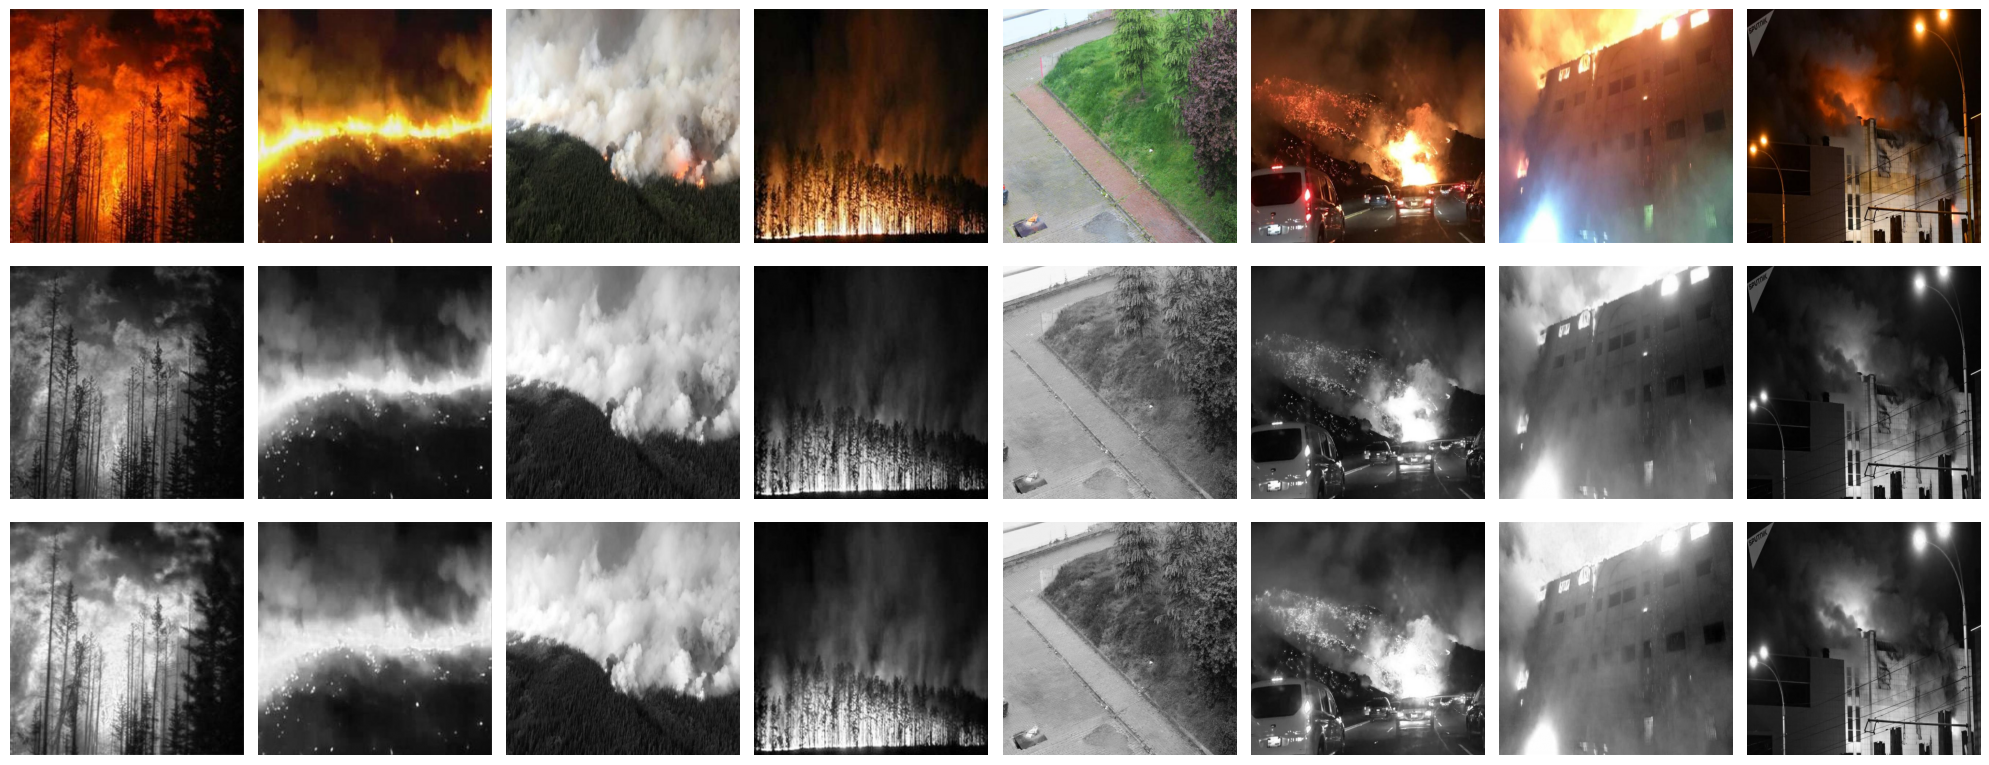

In [6]:
# Mostramos las imágen original en RGB junto a su versión en escala de grises
fig, axs = plt.subplots(3, 8, figsize=(20, 8))
for i, image_path in enumerate(select_path):
    # Leer imagen en RGB
    img_rgb = read_img.read_image_as_rgb(image_path)
    axs[0, i].imshow(img_rgb)
    axs[0, i].axis('off')

    # Leer imagen en escala de grises
    img_gray = read_img.read_image_as_grayscale(image_path, mode='normal')
    axs[1, i].imshow(img_gray, cmap='gray')
    axs[1, i].axis('off')

    # Leer imagen en escala de grises (modo personalizado)
    img_gray_custom = read_img.read_image_as_grayscale(image_path, mode='custom')
    axs[2, i].imshow(img_gray_custom, cmap='gray')
    axs[2, i].axis('off')

plt.tight_layout()
plt.show()

# Guardamos la figura con las imágenes originales y en escala de grises
output_path = os.path.join(avance2_base, 'figuras/imagenes_rgb_gris.png')
fig.savefig(output_path, dpi=500, bbox_inches='tight')